<a href="https://colab.research.google.com/github/nanomelk/Analista-de-Datos-II/blob/main/ABP2_Home_Credit_Default_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EVIDENCIA 1 - Comprensión del Negocio - Datos - Análisis exploratorio**

---



# **COMPRENSIÓN DEL PROBLEMA DE NEGOCIO**

### **Contexto Financiero y Necesidad**
En el sector crediticio, la evaluación precisa del riesgo es fundamental para la sostenibilidad y rentabilidad de la entidad. Otorgar créditos a clientes que posteriormente incurren en mora genera pérdidas financieras directas por capital no recuperado y eleva los costos de cobranza. Por otro lado, mantener un criterio de aprobación extremadamente rígido provoca el rechazo de clientes solventes, reduciendo los ingresos por intereses. La entidad financiera necesita optimizar la toma de decisiones para maximizar la aprobación de créditos rentables y controlar la tasa de morosidad.

---

### **Objetivo del Proyecto**
El objetivo principal de esta Prueba de Concepto (PoC) es desarrollar y evaluar un modelo predictivo (Regresión Logística) capaz de estimar la probabilidad de incumplimiento de pago (*default*) de los solicitantes de crédito a partir del archivo `application_train.csv`.

* **`TARGET = 0`**: Cliente que cumple correctamente sus pagos.
* **`TARGET = 1`**: Cliente que presenta incumplimiento o *default*.

---

### **Valor del Machine Learning para el Negocio**
La implementación de una solución basada en aprendizaje automático aporta un valor estratégico directo a la gestión del riesgo crediticio:

1. **Optimización de la Cartera y Rentabilidad:**
   * Minimiza el riesgo de morosidad al identificar patrones sutiles de incumplimiento.
   * Reduce el costo de oportunidad al evitar el rechazo injustificado de solicitantes aptos.

2. **Automatización y Consistencia:**
   * Permite evaluar solicitudes de forma estandarizada, rápida y sin sesgos subjetivos.

3. **Detección de Patrones Complejos:**
   * Identifica interacciones entre múltiples variables (socioeconómicas, demográficas y de scoring externo) que las reglas tradicionales basadas en umbrales fijos no capturan.

4. **Estrategia de Riesgo-Precio (*Risk-Based Pricing*):**
   * Al estimar la probabilidad continua de default de cada solicitante, la entidad puede graduar los montos de crédito, ajustar las tasas de interés o solicitar garantías adicionales según el perfil de riesgo del cliente.

---



### **Pregunta de Negocio**
> ¿Cómo podemos predecir con precisión la probabilidad de incumplimiento de pago (*default*) de los solicitantes de crédito a partir de su perfil socioeconómico y financiero, para optimizar las aprobaciones y reducir la tasa de morosidad sin impactar el crecimiento de la cartera?

# CARGA DE LIBRERÍAS

In [ ]:
#Montar Google Drive en Colab
#from google.colab import drive
#drive.mount('/content/drive')

# Importar las librerías principales de Ciencia de Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
%matplotlib inline
pd.set_option('display.max_columns', None)


In [ ]:
import os
import pandas as pd
from IPython.display import display

# 1. Configurar credenciales de Kaggle
# Reemplaza 'TU_USUARIO' y 'TU_KAGGLE_KEY' con las credenciales de tu archivo kaggle.json
os.environ['KAGGLE_API_TOKEN'] = "KGAT_beeea6ac31f6e1690b6f694660ebd8df"


# 2. Actualizar la herramienta de Kaggle
!pip install --upgrade -q kaggle

# 3. Descargar el dataset de la competencia desde Kaggle
print("--- Descargando datasets desde Kaggle ---")
!kaggle competitions download -c home-credit-default-risk

# 4. Descomprimir los archivos (-o reemplaza automáticamente, -q lo hace sin spam de texto)
print("--- Descomprimiendo archivos ---")
!unzip -o -q home-credit-default-risk.zip

# 5. Descargar el archivo auxiliar desde GitHub
print("--- Descargando Analisis_Previo.xlsx desde GitHub ---")
!curl -s -L -o Analisis_Previo.xlsx "https://raw.githubusercontent.com/nanomelk/Analista-de-Datos-II/main/Analisis_Previo.xlsx"

# 6. Cargar todos los DataFrames en Pandas
print("\n--- Cargando DataFrames en memoria ---")
df_train = pd.read_csv('application_train.csv')
df_test = pd.read_csv('application_test.csv')

df_prev_app = pd.read_csv('previous_application.csv')
df_pos_cash = pd.read_csv('POS_CASH_balance.csv')
df_installments = pd.read_csv('installments_payments.csv')
df_credit_card = pd.read_csv('credit_card_balance.csv')

df_bureau = pd.read_csv('bureau.csv')
df_bureau_balance = pd.read_csv('bureau_balance.csv')

df_sub = pd.read_csv('sample_submission.csv')
df_columns_desc = pd.read_csv('HomeCredit_columns_description.csv', encoding='latin1')
df_analisis = pd.read_excel('Analisis_Previo.xlsx', header=4)

print("✅ Todos los archivos cargados correctamente.")

# 7. Vista previa de los datos
display(df_train.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.4 MB/s eta 0:00:00
--- Descargando datasets desde Kaggle ---
100% 688M/688M [00:19<00:00, 36.2MB/s]

--- Descomprimiendo archivos ---
--- Descargando Analisis_Previo.xlsx desde GitHub ---

--- Cargando DataFrames en memoria ---
✅ Todos los archivos cargados correctamente.


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [ ]:
"""import os
from google.colab import auth
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from oauth2client.client import GoogleCredentials
import zipfile

# 1. Autenticar tu sesión de Google
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# 2. Buscar el archivo zip dentro de tus compartidos
file_list = drive.ListFile({'q': "title = 'home-credit-default-risk.zip' and trashed = false"}).GetList()

if file_list:
    zip_id = file_list[0]['id']
    print(f"Descargando archivo ZIP (ID: {zip_id})...")

    zip_file = drive.CreateFile({'id': zip_id})
    zip_file.GetContentFile('home-credit-default-risk.zip')

    # 3. Descomprimir todos los CSVs en el directorio actual
    print("Descomprimiendo archivos...")
    with zipfile.ZipFile('home-credit-default-risk.zip', 'r') as zip_ref:
        zip_ref.extractall('.')

    print("¡Listo! Archivos descomprimidos:")
    print([f for f in os.listdir('.') if f.endswith('.csv')])
else:
    print("No se encontró el archivo zip en Compartidos conmigo.")"""

'import os\nfrom google.colab import auth\nfrom pydrive2.auth import GoogleAuth\nfrom pydrive2.drive import GoogleDrive\nfrom oauth2client.client import GoogleCredentials\nimport zipfile\n\n# 1. Autenticar tu sesión de Google\nauth.authenticate_user()\ngauth = GoogleAuth()\ngauth.credentials = GoogleCredentials.get_application_default()\ndrive = GoogleDrive(gauth)\n\n# 2. Buscar el archivo zip dentro de tus compartidos\nfile_list = drive.ListFile({\'q\': "title = \'home-credit-default-risk.zip\' and trashed = false"}).GetList()\n\nif file_list:\n    zip_id = file_list[0][\'id\']\n    print(f"Descargando archivo ZIP (ID: {zip_id})...")\n\n    zip_file = drive.CreateFile({\'id\': zip_id})\n    zip_file.GetContentFile(\'home-credit-default-risk.zip\')\n\n    # 3. Descomprimir todos los CSVs en el directorio actual\n    print("Descomprimiendo archivos...")\n    with zipfile.ZipFile(\'home-credit-default-risk.zip\', \'r\') as zip_ref:\n        zip_ref.extractall(\'.\')\n\n    print("¡Listo!

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB




*   307,511 Registros totales — Cada fila representa un solicitante de crédito único.
*  122 Características — Atributos sobre el perfil del cliente y el tipo de solicitud.





In [ ]:
# visualizacion de los 3 primeros registros
df_train.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [ ]:
# visualizacion de datos estadisticos de las variables
df_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

In [ ]:
# Conteo del tipo de dato agrupado en columnas
conteo_tipos = df_train.dtypes.value_counts().reset_index()
conteo_tipos.columns = ['Tipo de Dato', 'Cantidad de Columnas']

display(conteo_tipos)

,Tipo de Dato,Cantidad de Columnas
0,float64,65
1,int64,41
2,object,16


In [ ]:
# Con el objetivo de comprender el Dataset, se visualizan las variables con tipo de dato "object"

# Filtrar solo las columnas categóricas (objeto)
cols_object = df_train.select_dtypes(include=['object'])

# Ver la cantidad de columnas objeto y sus primeras filas
print(f"Total de columnas categóricas: {cols_object.shape[1]}\n")
display(cols_object.head())

Total de columnas categóricas: 16



,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,NaN,NaN,NaN


In [ ]:
# Analisis de los valores únicos que posee cada columna categórica
df_train.select_dtypes(include=['object']).nunique()

,0
NAME_CONTRACT_TYPE,2
CODE_GENDER,3
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
NAME_TYPE_SUITE,7
NAME_INCOME_TYPE,8
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
OCCUPATION_TYPE,18


# **Detección y Tratamiento de Valores Faltantes**

## Función para detección de valores nulos

In [ ]:
# DETECCION DE NULOS
# Esta función analiza la calidad de datos de un DataFrame, identificando qué campos tienen valores nulos o faltantes
# y exporta ese reporte a un archivo local.

def analizar_y_guardar_faltantes(df: pd.DataFrame, ruta_salida: str = "datos_faltantes.csv") -> pd.DataFrame:
    """
    Calcula la cantidad, porcentaje de datos faltantes y tipo de dato por columna
    en un DataFrame, y exporta el resultado a un archivo (CSV o Excel).
    """
    # 1. Obtenemos el conteo de nulos y el tipo de dato por columna
    nulos_por_columna = df.isna().sum()
    tipos_de_datos = df.dtypes

    # 2. Construimos el DataFrame de resultados
    df_resultado = pd.DataFrame({
        'columna': nulos_por_columna.index,
        'tipo_dato': tipos_de_datos.astype(str).values,
        'faltantes': nulos_por_columna.values,
        'porcentaje': (nulos_por_columna.values / len(df) * 100).round(2)
    })

    # 3. Guardar el archivo en formato CSV o Excel según la extensión
    if ruta_salida.endswith('.xlsx'):
        df_resultado.to_excel(ruta_salida, index=False)
    else:
        df_resultado.to_csv(ruta_salida, index=False)

    print(f"Reporte de faltantes guardado correctamente en: {ruta_salida}")

    return df_resultado

In [ ]:
# 1. Calcular nulos totales y su porcentaje por columna
valores_nulos_totales = df_train.isnull().sum()
porcentaje_nulos = (valores_nulos_totales / len(df_train)) * 100

# 2. Unir ambos datos en un DataFrame ordenado
tabla_nulos = pd.DataFrame({
    'Valores Nulos': valores_nulos_totales,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

# 3. Filtrar solo las columnas que SI tienen nulos y ordenar de mayor a menor
tabla_nulos = tabla_nulos[tabla_nulos['Valores Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

print(f"Total de columnas con valores nulos: {len(tabla_nulos)}")
display(tabla_nulos)

Total de columnas con valores nulos: 67


,Valores Nulos,Porcentaje (%)
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
...,...,...
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00


## **Criterio de Tratamiento para Variables con Alto Porcentaje de Datos Faltantes**

Al analizar la distribución de los valores nulos en el dataset, se observa que una gran cantidad de columnas superan el 40% y 50% de datos ausentes (alcanzando en varios casos casi un 70%).

Ante un volumen de datos faltantes tan elevado, la estrategia metodológica que tomamos para tratar dichas variables es el de la eliminacion de las mismas en lugar de aplicar técnicas de imputación (relleno por media o mediana) por los siguientes motivos técnicos y estadísticos:


1.   **Introducción de Sesgos Severos:** Imputar artificialmente más del 40% de los registros en una columna altera de forma sustancial la varianza, la desviación estándar y la distribución original de la variable, distorsionando la realidad de los datos.

2.   **Inyección de Ruido al Modelo:** Rellenar valores masivamente con supuestos genera patrones ficticios que no aportan información predictiva real y pueden perjudicar el desempeño y la capacidad de generalización de los algoritmos de Machine Learning.

3.   **Pérdida de Representatividad:** Cuando la ausencia de información es tan masiva, la variable pierde su utilidad analítica para caracterizar la población de clientes.



---



### **Estrategia a aplicar:**

Se mantendrán únicamente aquellas variables cuyo porcentaje de nulos sea inferior a un umbral operativo (ej. < 50%), reservando la imputación estadística exclusivamente para variables clave con porcentajes de ausencia marginales (< 5%).

In [ ]:
#  Identificar las columnas a conservar(menos del 50% de nulos)
columnas_validas = tabla_nulos[tabla_nulos['Porcentaje (%)'] < 50].index

# Incluir las columnas que no tenían ningún nulo
columnas_sin_nulos = df_train.columns.difference(tabla_nulos.index)
todas_las_columnas_a_conservar = columnas_sin_nulos.union(columnas_validas)

#  Crear un nuevo dataset reducido por columnas (Se crea un nuevo Dataframe 'df_reducido' para trabajar la transformación.
#  Esto evita la mutación de datos y conserva 'df_train' como fuente intacta)
df_reducido = df_train[todas_las_columnas_a_conservar].copy()

#  Comprobar dimensiones
print(f"Dataset original (df_train): {df_train.shape[1]} columnas")
print(f"Nuevo dataset (df_reducido): {df_reducido.shape[1]} columnas")
print(f"Columnas descartadas por exceso de nulos: {df_train.shape[1] - df_reducido.shape[1]}")

Dataset original (df_train): 122 columnas
Nuevo dataset (df_reducido): 81 columnas
Columnas descartadas por exceso de nulos: 41


### **Analisis de las 41 columnas con una cantidad de datos nulos superior al 50%**

In [ ]:
#Identificar las 41 columnas con más del 50% de nulos
porcentaje_nulos = (df_train.isnull().sum() / len(df_train)) * 100
columnas_eliminadas = porcentaje_nulos[porcentaje_nulos > 50].index.tolist()

#Crear el dataset reducido (81 columnas)
df_reducido = df_train.drop(columns=columnas_eliminadas).copy()

#Mostrar la lista exacta de las columnas eliminadas
print(f"Total de columnas eliminadas: {len(columnas_eliminadas)}\n")
print(columnas_eliminadas)


Total de columnas eliminadas: 41

['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


### **Listado Detallado de las 41 Columnas Eliminadas (> 50% de Nulos)**

Se descartaron exactamente **41 variables** por superar el 50% de datos faltantes para evitar sesgar el análisis mediante imputaciones artificiales:

| # | Nombre de la Columna | Categoría | Descripción |
| :-: | :--- | :--- | :--- |
| **1** | `OWN_CAR_AGE` | Vehículo | Antigüedad (en años) del vehículo del cliente. |
| **2** | `EXT_SOURCE_1` | Scoring Externo | Puntuación normalizada proveniente de la fuente externa #1. |
| **3** | `APARTMENTS_AVG` | Vivienda (Promedio) | Tamaño del departamento normalizado. |
| **4** | `APARTMENTS_MODE` | Vivienda (Moda) | Tamaño del departamento normalizado. |
| **5** | `APARTMENTS_MEDI` | Vivienda (Mediana) | Tamaño del departamento normalizado. |
| **6** | `BASEMENTAREA_AVG` | Vivienda (Promedio) | Área del sótano normalizada. |
| **7** | `BASEMENTAREA_MODE` | Vivienda (Moda) | Área del sótano normalizada. |
| **8** | `BASEMENTAREA_MEDI` | Vivienda (Mediana) | Área del sótano normalizada. |
| **9** | `YEARS_BUILD_AVG` | Vivienda (Promedio) | Antigüedad / año de construcción del edificio. |
| **10** | `YEARS_BUILD_MODE` | Vivienda (Moda) | Antigüedad / año de construcción del edificio. |
| **11** | `YEARS_BUILD_MEDI` | Vivienda (Mediana) | Antigüedad / año de construcción del edificio. |
| **12** | `COMMONAREA_AVG` | Vivienda (Promedio) | Área común del inmueble normalizada. |
| **13** | `COMMONAREA_MODE` | Vivienda (Moda) | Área común del inmueble normalizada. |
| **14** | `COMMONAREA_MEDI` | Vivienda (Mediana) | Área común del inmueble normalizada. |
| **15** | `ELEVATORS_AVG` | Vivienda (Promedio) | Cantidad de ascensores en el edificio. |
| **16** | `ELEVATORS_MODE` | Vivienda (Moda) | Cantidad de ascensores en el edificio. |
| **17** | `ELEVATORS_MEDI` | Vivienda (Mediana) | Cantidad de ascensores en el edificio. |
| **18** | `ENTRANCES_AVG` | Vivienda (Promedio) | Cantidad de entradas al edificio. |
| **19** | `ENTRANCES_MODE` | Vivienda (Moda) | Cantidad de entradas al edificio. |
| **20** | `ENTRANCES_MEDI` | Vivienda (Mediana) | Cantidad de entradas al edificio. |
| **21** | `FLOORSMAX_AVG` | Vivienda (Promedio) | Número máximo de pisos en el edificio. |
| **22** | `FLOORSMIN_AVG` | Vivienda (Promedio) | Número mínimo de pisos en el edificio. |
| **23** | `FLOORSMIN_MODE` | Vivienda (Moda) | Número mínimo de pisos en el edificio. |
| **24** | `FLOORSMIN_MEDI` | Vivienda (Mediana) | Número mínimo de pisos en el edificio. |
| **25** | `LANDAREA_AVG` | Vivienda (Promedio) | Área del terreno normalizada. |
| **26** | `LANDAREA_MODE` | Vivienda (Moda) | Área del terreno normalizada. |
| **27** | `LANDAREA_MEDI` | Vivienda (Mediana) | Área del terreno normalizada. |
| **28** | `LIVINGAPARTMENTS_AVG` | Vivienda (Promedio) | Área departamental habitable normalizada. |
| **29** | `LIVINGAPARTMENTS_MODE` | Vivienda (Moda) | Área departamental habitable normalizada. |
| **30** | `LIVINGAPARTMENTS_MEDI` | Vivienda (Mediana) | Área departamental habitable normalizada. |
| **31** | `LIVINGAREA_AVG` | Vivienda (Promedio) | Área habitable total normalizada. |
| **32** | `LIVINGAREA_MODE` | Vivienda (Moda) | Área habitable total normalizada. |
| **33** | `LIVINGAREA_MEDI` | Vivienda (Mediana) | Área habitable total normalizada. |
| **34** | `NONLIVINGAPARTMENTS_AVG` | Vivienda (Promedio) | Área departamental no habitable normalizada. |
| **35** | `NONLIVINGAPARTMENTS_MODE` | Vivienda (Moda) | Área departamental no habitable normalizada. |
| **36** | `NONLIVINGAPARTMENTS_MEDI` | Vivienda (Mediana) | Área departamental no habitable normalizada. |
| **37** | `NONLIVINGAREA_AVG` | Vivienda (Promedio) | Área no habitable total normalizada. |
| **38** | `NONLIVINGAREA_MODE` | Vivienda (Moda) | Área no habitable total normalizada. |
| **39** | `NONLIVINGAREA_MEDI` | Vivienda (Mediana) | Área no habitable total normalizada. |
| **40** | `HOUSETYPE_MODE` | Vivienda (Moda) | Tipo de vivienda u hogar. |
| **41** | `WALLSMATERIAL_MODE` | Vivienda (Moda) | Material de construcción de las paredes externas. |

---

> **Conclusión técnica:**
> * **39 variables de infraestructura:** Corresponden a detalles arquitectónicos de la vivienda que la mayoría de los clientes no declararon.
> * **`OWN_CAR_AGE`:** Presente únicamente en clientes que declararon poseer vehículo propio.
> * **`EXT_SOURCE_1`:** Score crediticio externo ausente en más del 50% de la muestra.

## **Estrategia de Categorización y Tratamiento de Valores Nulos Restantes**

Tras haber removido las columnas con ausencia masiva (> 50%), el dataset `df_reducido` aún presenta variables con datos faltantes. Debido a que la cantidad de nulos difiere sustancialmente entre columnas, no resulta conveniente aplicar una única técnica de imputación global, ya que esto podría sesgar la distribución de los datos o distorsionar patrones predictivos clave.

Para abordar este proceso de manera estratégica y metodológicamente rigurosa, se clasificaron las variables con nulos en tres franjas según su porcentaje de ausencia:

* **1. Nivel Alto (30% a 50%):** Reemplazar las ausencias por la etiqueta `Desconocido` en variables categóricas. En variables numéricas de este rango se aplicara una imputacion por mediana.
* **2. Nivel Medio (5% a 30%):** Se aplica imputación por **mediana**  para preservar el alto poder predictivo de estas métricas.
* **3. Nivel Bajo (< 5%):**  Al representar una pérdida de información mínima, el riesgo de distorsión estadística es bajo. Se aplica imputación directa por **mediana** para variables continuas y por la **moda** (valor más frecuente) para variables categóricas.


---


**Objetivo del Enfoque:**
Esta segmentación por niveles asegura un tratamiento diferenciado y adaptado al volumen de datos faltantes, preservando la calidad estadística del dataset antes de proceder con el modelado.

---



**Complementariamente al criterio cuantitativo "Evaluación por franjas de densidad de datos nulos", se llevará a cabo un análisis cualitativo e individual por variable. El objetivo es evaluar su relevancia del negocio y capacidad predictiva respecto al fenómeno en estudio. De este modo, la decisión final de inclusión o descarte no dependerá únicamente del volumen de faltantes; variables con baja tasa de ausencias podrían ser omitidas por redundancia o falta de poder explicativo, mientras que variables pertenecientes a franjas de alta vaciedad podrían ser retenidas e imputadas mediante técnicas avanzadas si aportan valor crítico al modelo**.






In [ ]:
#Calcular nulos y porcentajes únicamente sobre df_reducido
nulos = df_reducido.isnull().sum()
porcentajes = (nulos / len(df_reducido)) * 100

#Filtrar solo las columnas que conservan nulos (> 0%)
df_nulos = pd.DataFrame(
    {
        'Columna': nulos.index,
        'Tipo_Dato': df_reducido.dtypes.values,
        'Valores_Nulos': nulos.values,
        'Porcentaje (%)': porcentajes.round(2).values,
    }
)
df_nulos = df_nulos[df_nulos['Valores_Nulos'] > 0]


#Función para clasificar en las 3 franjas de criticidad
def clasificar_franja(pct):
    if pct >= 30:
        return '1. Alto (30% - 50%)'
    elif pct >= 5:
        return '2. Medio (5% - 30%)'
    else:
        return '3. Bajo (< 5%)'


df_nulos['Franja'] = df_nulos['Porcentaje (%)'].apply(clasificar_franja)

#Ordenar y mostrar la tabla agrupada
tabla_clasificada = df_nulos.sort_values(
    by=['Franja', 'Porcentaje (%)'], ascending=[True, False]
)

display(tabla_clasificada.reset_index(drop=True))



,Columna,Tipo_Dato,Valores_Nulos,Porcentaje (%),Franja
0,FLOORSMAX_AVG,float64,153020,49.76,1. Alto (30% - 50%)
1,FLOORSMAX_MODE,float64,153020,49.76,1. Alto (30% - 50%)
2,FLOORSMAX_MEDI,float64,153020,49.76,1. Alto (30% - 50%)
3,YEARS_BEGINEXPLUATATION_AVG,float64,150007,48.78,1. Alto (30% - 50%)
4,YEARS_BEGINEXPLUATATION_MODE,float64,150007,48.78,1. Alto (30% - 50%)
5,YEARS_BEGINEXPLUATATION_MEDI,float64,150007,48.78,1. Alto (30% - 50%)
6,TOTALAREA_MODE,float64,148431,48.27,1. Alto (30% - 50%)
7,EMERGENCYSTATE_MODE,object,145755,47.40,1. Alto (30% - 50%)
8,OCCUPATION_TYPE,object,96391,31.35,1. Alto (30% - 50%)
9,EXT_SOURCE_3,float64,60965,19.83,2. Medio (5% - 30%)


### **Resumen General de la Distribución de Variables (122 Columnas Totales)**

El total de **122 variables** del dataset original se clasificó de la siguiente manera:

* **Columnas Eliminadas (41 variables):** Superaban el 50% de valores faltantes.
* **Dataset Reducido / Conservado (81 variables):**
  * **Sin nulos (55 columnas):** Tienen el **100% de sus datos completos**.
  * **Con nulos (26 columnas):** Variables que conservan faltantes y serán imputadas:
    * **Franja Alta (30% - 50%):** 9 columnas
    * **Franja Media (5% - 30%):** 7 columnas
    * **Franja Baja (< 5%):** 10 columnas

---

### **Desglose de las 26 Variables a Imputar por Franja**

#### **1. Franja Alta (30% a 50% de Nulos - 9 columnas)**

| Nombre de la Columna | Tipo de Dato | % Nulos | Descripción |
| :--- | :--- | :-: | :--- |
| **`FLOORSMAX_AVG`** | Numérico | 49.76% | Número máximo de pisos en el edificio (promedio). |
| **`FLOORSMAX_MODE`** | Numérico | 49.76% | Número máximo de pisos en el edificio (moda). |
| **`FLOORSMAX_MEDI`** | Numérico | 49.76% | Número máximo de pisos en el edificio (mediana). |
| **`YEARS_BEGINEXPLUATATION_AVG`** | Numérico | 48.78% | Antigüedad/inicio de explotación del edificio (promedio). |
| **`YEARS_BEGINEXPLUATATION_MODE`** | Numérico | 48.78% | Antigüedad/inicio de explotación del edificio (moda). |
| **`YEARS_BEGINEXPLUATATION_MEDI`** | Numérico | 48.78% | Antigüedad/inicio de explotación del edificio (mediana). |
| **`TOTALAREA_MODE`** | Numérico | 48.27% | Área total del inmueble normalizada (moda). |
| **`EMERGENCYSTATE_MODE`** | Categórico | 47.40% | Indicador si la vivienda presenta estado de emergencia/riesgo. |
| **`OCCUPATION_TYPE`** | Categórico | 31.35% | Tipo de ocupación, profesión u oficio que desempeña el cliente. |

---

#### **2. Franja Media (5% a 30% de Nulos - 7 columnas)**

| Nombre de la Columna | Tipo de Dato | % Nulos | Descripción |
| :--- | :--- | :-: | :--- |
| **`EXT_SOURCE_3`** | Numérico | 19.83% | Puntuación/score de riesgo normalizado de la fuente externa #3. |
| **`AMT_REQ_CREDIT_BUREAU_HOUR`** | Numérico | 13.50% | Consultas al Bureau de Crédito 1 hora antes de la solicitud. |
| **`AMT_REQ_CREDIT_BUREAU_DAY`** | Numérico | 13.50% | Consultas al Bureau de Crédito 1 día antes de la solicitud. |
| **`AMT_REQ_CREDIT_BUREAU_WEEK`** | Numérico | 13.50% | Consultas al Bureau de Crédito 1 semana antes de la solicitud. |
| **`AMT_REQ_CREDIT_BUREAU_MON`** | Numérico | 13.50% | Consultas al Bureau de Crédito 1 mes antes de la solicitud. |
| **`AMT_REQ_CREDIT_BUREAU_QRT`** | Numérico | 13.50% | Consultas al Bureau de Crédito 3 meses antes de la solicitud. |
| **`AMT_REQ_CREDIT_BUREAU_YEAR`** | Numérico | 13.50% | Consultas al Bureau de Crédito 1 año antes de la solicitud. |

---

#### **3. Franja Baja (< 5% de Nulos - 10 columnas)**

| Nombre de la Columna | Tipo de Dato | % Nulos | Descripción |
| :--- | :--- | :-: | :--- |
| **`NAME_TYPE_SUITE`** | Categórico | 0.42% | Acompañante presente al solicitar el préstamo. |
| **`OBS_30_CNT_SOCIAL_CIRCLE`** | Numérico | 0.33% | Personas del entorno social observadas con atrasos de 30 días. |
| **`DEF_30_CNT_SOCIAL_CIRCLE`** | Numérico | 0.33% | Personas del entorno social que cayeron en mora a 30 días. |
| **`OBS_60_CNT_SOCIAL_CIRCLE`** | Numérico | 0.33% | Personas del entorno social observadas con atrasos de 60 días. |
| **`DEF_60_CNT_SOCIAL_CIRCLE`** | Numérico | 0.33% | Personas del entorno social que cayeron en mora a 60 días. |
| **`EXT_SOURCE_2`** | Numérico | 0.21% | Puntuación/score de riesgo normalizado de la fuente externa #2. |
| **`AMT_GOODS_PRICE`** | Numérico | 0.09% | Precio del bien o servicio para el cual se otorga el crédito. |
| **`AMT_ANNUITY`** | Numérico | <0.01% | Monto de la cuota/anualidad fija a pagar por el préstamo. |
| **`CNT_FAM_MEMBERS`** | Numérico | <0.01% | Cantidad total de integrantes dentro del grupo familiar. |
| **`DAYS_LAST_PHONE_CHANGE`** | Numérico | <0.01% | Días transcurridos desde que el cliente cambió su teléfono. |

Dado el elevado volumen de variables remanentes por evaluar —un total de 81 características, compuestas por 55 sin valores nulos y 26 con datos faltantes en proporciones que oscilaban entre el 5% y cerca del 50%— y comprendiendo que múltiples campos no aportaban valor predictivo real al problema de negocio abordado, el equipo optó por realizar una evaluación cualitativa individual. Apoyándonos en el conocimiento del dominio del problema y asistidos por herramientas de inteligencia artificial, seleccionamos un conjunto prioritario de variables (pool de trabajo) sobre el cual enfocar los esfuerzos de limpieza y preparación. Esta estrategia de selección no solo optimiza el uso de recursos, sino que previene el sobreajuste y la degradación del rendimiento en los algoritmos de aprendizaje automático, los cuales suelen verse perjudicados por la presencia de características ruidosas o irrelevantes.

In [ ]:
# ==============================================================================
# VARIABLES PRIORITARIAS PARA EL ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==============================================================================
"""
A continuación se detallan las variables clave del archivo 'application_train.csv'
que se conservarán para la Evidencia 1, estructuradas según el tipo de información.

+------------------------+---------------------+-----------------------------------------------+---------------------------------------------------------------------------------------------------------+
| Tipo Variable          | Variable            | Descripción                                   | Fundamento                                                                                              |
+------------------------+---------------------+-----------------------------------------------+---------------------------------------------------------------------------------------------------------+
| Variable Objetivo      | TARGET              | 1 = Cliente en default, 0 = Paga bien         | Variable central de predicción. Presenta fuerte desbalance (~92% vs 8%) que fundamenta el uso de AUC-ROC. [2, 3]
| Variables Financieras  | AMT_INCOME_TOTAL    | Ingresos totales declarados del cliente       | Mide la capacidad económica básica para hacer frente al préstamo solicitado. [4]                       |
| Variables Financieras  | AMT_CREDIT          | Monto neto del préstamo otorgado              | Determina la magnitud del riesgo de crédito asumido por la financiera. [4]                             |
| Variables Financieras  | AMT_ANNUITY         | Cuota mensual de amortización del crédito     | Esencial para evaluar la tasa de esfuerzo de pago sobre los ingresos declarados. [5]                   |
| Variables Financieras  | AMT_GOODS_PRICE     | Precio del bien para el que se pide el crédito| Relación entre el valor del bien de consumo y el préstamo otorgado (LTV). [5]                         |
| Variables Demográficas | CODE_GENDER         | Género del solicitante                        | Segmentación básica y detección de sesgos o patrones de comportamiento demográfico. [5]                 |
| Variables Demográficas | NAME_EDUCATION_TYPE | Máximo nivel académico alcanzado              | Se correlaciona con la estabilidad laboral, formalidad de ingresos y menor riesgo histórico. [5]       |
| Variables Demográficas | NAME_FAMILY_STATUS  | Estado civil                                  | Informa sobre la estructura de responsabilidades del hogar y gastos compartidos. [5]                    |
| Variables Demográficas | NAME_INCOME_TYPE    | Actividad económica que genera ingresos       | Determina la regularidad y predictibilidad de los ingresos para el pago mensual. [5]                    |
| Variables Demográficas | NAME_HOUSING_TYPE   | Tipo de vivienda (alquiler, propia, etc.)     | Identifica costos de vivienda implícitos y el nivel de arraigo residencial. [5]                        |
| Variables Demográficas | CNT_CHILDREN        | Cantidad de hijos declarados                  | Carga financiera del hogar. Requiere limpieza previa por outliers con errores de carga (ej. 20 hijos). [5, 6]
| Variables Demográficas | CNT_FAM_MEMBERS     | Total de miembros del grupo familiar          | Permite dimensionar la base mínima de egresos necesarios para el sustento del hogar. [5]               |
| Tiempos Relativos      | DAYS_BIRTH          | Edad en días al momento de la solicitud       | Predictor de madurez de pago. Se debe transformar a años durante el EDA. [5]                           |
| Tiempos Relativos      | DAYS_EMPLOYED       | Antigüedad laboral medida en días             | Indicador de estabilidad económica. Requiere tratar el valor anómalo de 365243 (jubilados/desempleo). [5, 7]|
| Tiempos Relativos      | DAYS_REGISTRATION   | Días desde el último cambio de dirección      | Proxy indirecto de estabilidad geográfica y arraigo local. [5]                                         |
| Tiempos Relativos      | DAYS_ID_PUBLISH     | Días desde la renovación del documento        | Control operacional; valida que la identificación física no esté desactualizada. [5]                  |
| Scores Externos        | EXT_SOURCE_1        | Score crediticio de fuente externa 1          | Altísima correlación con default. Aunque sea "caja negra", es crítico para el modelo predictivo. [5, 7]|
| Scores Externos        | EXT_SOURCE_2        | Score crediticio de fuente externa 2          | Fuente de buró externa con mayor poder discriminante de mora en este dataset. [5]                      |
| Scores Externos        | EXT_SOURCE_3        | Score crediticio de fuente externa 3          | Complementa la terna de scores externos, mejorando sustancialmente el baseline. [5]                    |
| Validación y Calidad   | FLAG_DOCUMENT_3     | Entregó el documento principal 3              | Único indicador de entrega de documentación útil con variabilidad estadística relevante. [8]           |
| Validación y Calidad   | OCCUPATION_TYPE     | Tipo de ocupación laboral específica          | Útil para micro-segmentar riesgo profesional, a pesar de tener >30% de nulos. [6]                      |
| Validación y Calidad   | NAME_CONTRACT_TYPE  | Tipo de préstamo (efectivo o rotativo)        | Identifica el tipo de amortización aplicable a la solicitud. [1, 9]                                   |
| Validación y Calidad   | FLAG_OWN_CAR        | Indica si el cliente es dueño de auto          | Proxy indirecto de patrimonio y activos de mediano plazo. [1]                                           |
| Validación y Calidad   | FLAG_OWN_REALTY     | Indica si posee propiedades inmuebles         | Refleja solvencia a largo plazo y un mayor compromiso de cumplimiento. [1]                              |
+------------------------+---------------------+-----------------------------------------------+---------------------------------------------------------------------------------------------------------+
"""

'\nA continuación se detallan las variables clave del archivo \'application_train.csv\'\nque se conservarán para la Evidencia 1, estructuradas según el tipo de información.\n\n+------------------------+---------------------+-----------------------------------------------+---------------------------------------------------------------------------------------------------------+\n| Tipo Variable          | Variable            | Descripción                                   | Fundamento                                                                                              |\n+------------------------+---------------------+-----------------------------------------------+---------------------------------------------------------------------------------------------------------+\n| Variable Objetivo      | TARGET              | 1 = Cliente en default, 0 = Paga bien         | Variable central de predicción. Presenta fuerte desbalance (~92% vs 8%) que fundamenta el uso de AUC-ROC. [2, 3]\n|

joel...estaa misma tabla, la saque del excel y la escribi abajo en formato markdown para que siguiera el formato y estetica del trabajo ...joel

# **Variables Prioritarias para el Analisis Exploratorio de Datos (EDA)**

| Tipo Variable | Variable | Descripción | Fundamento |
| --- | --- | --- | --- |
| Variable Objetivo | TARGET | Identificador de si el cliente presentó dificultades de pago o cayó en default (1) o si pagó correctamente (0). | Es la variable central de clasificación. Su análisis preliminar revela un severo desbalance de clases (~92% pagadores vs ~8% default) que justifica el uso de la métrica AUC-ROC en lugar de Accuracy. |
| Variables Financieras | AMT_INCOME_TOTAL | Ingresos declarados totales del solicitante. | Mide la capacidad de generación de ingresos, esencial para evaluar la solidez económica básica y el respaldo de la deuda. |
| Variables Financieras | AMT_CREDIT | Monto total de financiamiento otorgado en el préstamo. | Determina el tamaño del riesgo de crédito asumido por la financiera al otorgar el activo. |
| Variables Financieras | AMT_ANNUITY | Cuota periódica (anualidad/mensualidad) de amortización del crédito. | Indispensable para calcular ratios de endeudamiento y de esfuerzo financiero en relación al ingreso familiar. |
| Variables Financieras | AMT_GOODS_PRICE | Precio comercial del bien de consumo para el cual se solicita el crédito. | Permite conocer el porcentaje de financiamiento requerido (relación préstamo-valor del bien). |
| Variables Demográficas | CODE_GENDER | Género registrado del cliente. | Permite identificar sesgos y segmentar perfiles demográficos de riesgo básico. |
| Variables Demográficas | NAME_EDUCATION_TYPE | Máximo nivel de educación formal alcanzado por el cliente. | Se correlaciona fuertemente con la estabilidad laboral, la formalidad de ingresos y la probabilidad histórica de default. |
| Variables Demográficas | NAME_FAMILY_STATUS | Estado civil del cliente. | Aporta contexto sobre las responsabilidades financieras compartidas y la estructura de consumo en el hogar. |
| Variables Demográficas | NAME_INCOME_TYPE | Tipo de actividad que genera los ingresos del cliente (ej: asalariado, jubilado, independiente). | Determina la estabilidad y predictibilidad de los ingresos para el cumplimiento recurrente de cuotas. |
| Variables Demográficas | NAME_HOUSING_TYPE | Situación habitacional del cliente (ej. casa propia, alquilada, vive con padres). | Refleja costos de vivienda no explícitos y la estabilidad domiciliaria del solicitante. |
| Variables Demográficas | CNT_CHILDREN | Cantidad de hijos declarados por el cliente. | Mide cargas financieras fijas en el hogar; requiere un tratamiento previo debido a errores de carga detectados con outliers extremos (como 19 o 20 hijos). |
| Variables Demográficas | CNT_FAM_MEMBERS | Cantidad total de integrantes que conforman el grupo familiar. | Brinda un panorama completo de los egresos mínimos necesarios para la subsistencia de la familia. |
| Variables de Tiempos Relativos | DAYS_BIRTH | Edad del cliente expresada en días relativos a la fecha de la solicitud. | Representa un predictor de madurez y comportamiento de pago. Se debe transformar a años durante el EDA para su correcta interpretación por rango etario. |
| Variables de Tiempos Relativos | DAYS_EMPLOYED | Antigüedad laboral del cliente en días al momento de aplicar. | Esencial para medir la estabilidad económica. Es un punto de calidad de datos crítico por el valor anómalo de 365,243 días (que equivale a 1000 años e indica jubilación/desempleo). |
| Variables de Tiempos Relativos | DAYS_REGISTRATION | Días transcurridos desde que el cliente actualizó su registro oficial de domicilio. | Proxy de arraigo y estabilidad geográfica del solicitante en su localidad. |
| Variables de Tiempos Relativos | DAYS_ID_PUBLISH | Días transcurridos desde que el cliente renovó el documento de identidad entregado. | Útil para validar la vigencia de la identificación del cliente y detectar comportamientos anómalos. |
| Scores de Fuentes Externas | EXT_SOURCE_1 | Puntaje de crédito normalizado obtenido de una base de datos externa 1. | Es de las variables con mayor correlación lineal e impacto en el default, a pesar de funcionar temporalmente como "caja negra" para la regresión logística. |
| Scores de Fuentes Externas | EXT_SOURCE_2 | Puntaje de crédito normalizado obtenido de una base de datos externa 2. | Aporta un altísimo poder predictivo general y es fundamental para construir el modelo baseline de riesgo. |
| Scores de Fuentes Externas | EXT_SOURCE_3 | Puntaje de crédito normalizado obtenido de una base de datos externa 3. | Complementa la terna de scores externos que históricamente dominan la capacidad explicativa del modelo en este dataset. |
| Validación / Calidad Especial | FLAG_DOCUMENT_3 | Bandera binaria que indica si el cliente entregó el documento principal 3. | Es el único indicador de entrega documental útil, ya que presenta variabilidad estadística relevante a diferencia de los otros 19 flags. |
| Validación / Calidad Especial | OCCUPATION_TYPE | Oficio o profesión específica del solicitante. | Aporta gran valor para micro-segmentar el riesgo profesional, aunque se debe gestionar que posee más de un 30% de valores nulos. |
| Validación / Calidad Especial | NAME_CONTRACT_TYPE | Tipo de producto financiero solicitado (préstamo en efectivo o revolvente). | Define el esquema de amortización y tasa aplicable al producto crediticio. |
| Validación / Calidad Especial | FLAG_OWN_CAR | Bandera binaria de si el cliente es dueño de un automóvil. | Funciona como proxy patrimonial indirecto y mide el nivel de capitalización material del solicitante. |
| Validación / Calidad Especial | FLAG_OWN_REALTY | Bandera binaria de si el cliente posee propiedades inmobiliarias. | Indica solidez patrimonial de largo plazo y un perfil de cliente habitualmente más comprometido con el cumplimiento de pagos. |

## **Seleccion Previa de Variables Utiles**

In [ ]:
# Leer archivo excel denominado Analisis_Previo.xlsx que contiene la información de las variables a analizar y una breve descripción de cada una de ellas
# Los encabezados arrancan en la fila 4
#df_analisis = pd.read_excel('Analisis_Previo.xlsx', header=4)
import pandas as pd
from IPython.display import display

# 1. URL raw del archivo en GitHub
url = "https://raw.githubusercontent.com/nanomelk/Analista-de-Datos-II/main/Analisis_Previo.xlsx"

# 2. Descargar el archivo al entorno local de Colab usando curl
!curl -s -L -o Analisis_Previo.xlsx "{url}"

# 3. Leer el Excel con Pandas (aplicando header=4 como en tu script original)
df_analisis = pd.read_excel('Analisis_Previo.xlsx', header=4)

print("✅ Archivo cargado exitosamente desde GitHub:")
display(df_analisis)

✅ Archivo cargado exitosamente desde GitHub:


,Tipo Variable,Variable,Descripción,Fundamento
0,Variable Objetivo,TARGET,Identificador de si el cliente presentó dificu...,Es la variable central de clasificación. Su an...
1,Variables Financieras,AMT_INCOME_TOTAL,Ingresos declarados totales del solicitante.,"Mide la capacidad de generación de ingresos, e..."
2,Variables Financieras,AMT_CREDIT,Monto total de financiamiento otorgado en el p...,Determina el tamaño del riesgo de crédito asum...
3,Variables Financieras,AMT_ANNUITY,Cuota periódica (anualidad/mensualidad) de amo...,Indispensable para calcular ratios de endeudam...
4,Variables Financieras,AMT_GOODS_PRICE,Precio comercial del bien de consumo para el c...,Permite conocer el porcentaje de financiamient...
5,Variables Demográficas,CODE_GENDER,Género registrado del cliente.,Permite identificar sesgos y segmentar perfile...
6,Variables Demográficas,NAME_EDUCATION_TYPE,Máximo nivel de educación formal alcanzado por...,Se correlaciona fuertemente con la estabilidad...
7,Variables Demográficas,NAME_FAMILY_STATUS,Estado civil del cliente.,Aporta contexto sobre las responsabilidades fi...
8,Variables Demográficas,NAME_INCOME_TYPE,Tipo de actividad que genera los ingresos del ...,Determina la estabilidad y predictibilidad de ...
9,Variables Demográficas,NAME_HOUSING_TYPE,Situación habitacional del cliente (ej. casa p...,Refleja costos de vivienda no explícitos y la ...


In [ ]:
df_analisis.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tipo Variable  24 non-null     object
 1   Variable       24 non-null     object
 2   Descripción    24 non-null     object
 3   Fundamento     24 non-null     object
dtypes: object(4)
memory usage: 900.0+ bytes


In [ ]:
# Crear una lista con las columnas que se conservarán para el análisis final
columnas_a_conservar = df_analisis['Variable'].tolist()

In [ ]:
# Cargar el dataset (application_train.csv) con las columnas seleccionadas para el analisis
df = pd.read_csv('application_train.csv', usecols=columnas_a_conservar)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TARGET               307511 non-null  int64  
 1   NAME_CONTRACT_TYPE   307511 non-null  object 
 2   CODE_GENDER          307511 non-null  object 
 3   FLAG_OWN_CAR         307511 non-null  object 
 4   FLAG_OWN_REALTY      307511 non-null  object 
 5   CNT_CHILDREN         307511 non-null  int64  
 6   AMT_INCOME_TOTAL     307511 non-null  float64
 7   AMT_CREDIT           307511 non-null  float64
 8   AMT_ANNUITY          307499 non-null  float64
 9   AMT_GOODS_PRICE      307233 non-null  float64
 10  NAME_INCOME_TYPE     307511 non-null  object 
 11  NAME_EDUCATION_TYPE  307511 non-null  object 
 12  NAME_FAMILY_STATUS   307511 non-null  object 
 13  NAME_HOUSING_TYPE    307511 non-null  object 
 14  DAYS_BIRTH           307511 non-null  int64  
 15  DAYS_EMPLOYED    

In [ ]:
# identificar las columnas que tienen valores nulos en el dataset final
reporte_faltantes = analizar_y_guardar_faltantes(df, ruta_salida='reporte_faltantes_final.xlsx')

Reporte de faltantes guardado correctamente en: reporte_faltantes_final.xlsx


In [ ]:
# Visualizar el reporte de valores faltantes, para variables con porcentaje de nulos mayor a 0%
reporte_faltantes[reporte_faltantes['porcentaje'] > 0]

,columna,tipo_dato,faltantes,porcentaje
9,AMT_GOODS_PRICE,float64,278,0.09
18,OCCUPATION_TYPE,object,96391,31.35
20,EXT_SOURCE_1,float64,173378,56.38
21,EXT_SOURCE_2,float64,660,0.21
22,EXT_SOURCE_3,float64,60965,19.83


In [ ]:
# DESCRIBE DE LOS CAMPOS DE INTERES NUMERICOS

df.describe()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,FLAG_DOCUMENT_3
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,134133.000000,3.068510e+05,246546.000000,307511.000000
mean,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,-16036.995067,63815.045904,-4986.120328,-2994.202373,2.152665,0.502130,5.143927e-01,0.510853,0.710023
std,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,4363.988632,141275.766519,3522.886321,1509.450419,0.910682,0.211062,1.910602e-01,0.194844,0.453752
min,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,-25229.000000,-17912.000000,-24672.000000,-7197.000000,1.000000,0.014568,8.173617e-08,0.000527,0.000000
25%,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,-19682.000000,-2760.000000,-7479.500000,-4299.000000,2.000000,0.334007,3.924574e-01,0.370650,0.000000
50%,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,-15750.000000,-1213.000000,-4504.000000,-3254.000000,2.000000,0.505998,5.659614e-01,0.535276,1.000000
75%,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,-12413.000000,-289.000000,-2010.000000,-1720.000000,3.000000,0.675053,6.636171e-01,0.669057,1.000000
max,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,-7489.000000,365243.000000,0.000000,0.000000,20.000000,0.962693,8.549997e-01,0.896010,1.000000


In [ ]:
# DESCRIBE DE LOS CAMPOS NO NUMERICOS

df.select_dtypes(include='object').describe()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE
count,307511,307511,307511,307511,307511,307511,307511,307511,211120
unique,2,3,2,2,8,5,6,6,18
top,Cash loans,F,N,Y,Working,Secondary / secondary special,Married,House / apartment,Laborers
freq,278232,202448,202924,213312,158774,218391,196432,272868,55186


## **Limpieza de las variables a utilizar**

In [ ]:
# Definición explícita de tus 24 variables seleccionadas
VARIABLES_SELECCIONADAS = [
    'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
    'EXT_SOURCE_3', 'FLAG_DOCUMENT_3'
]

def verificar_variables(dataframe):
    """
    Verifica que las 24 variables estén presentes en el DataFrame.
    """
    faltantes = [var for var in VARIABLES_SELECCIONADAS if var not in dataframe.columns]
    if faltantes:
        print(f"⚠️ ATENCIÓN: Las siguientes variables no están en el DataFrame: {faltantes}")
    else:
        print("✅ Las 24 variables seleccionadas están presentes en el DataFrame.")


def corregir_inconsistencias_y_outliers(dataframe):
    """
    Corrige anomalías numéricas y convierte días relativos a años en todas las variables temporales.
    """
    df_clean = dataframe.copy()

    # 1. Tratar antigüedad laboral anómala (365243 días = 1000 años)
    if 'DAYS_EMPLOYED' in df_clean.columns:
        df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].replace(365243, np.nan)
        df_clean['ANOS_EMPLEO'] = df_clean['DAYS_EMPLOYED'].abs() / 365.25

    # 2. Convertir variables de días negativos a AÑOS POSITIVOS
    if 'DAYS_BIRTH' in df_clean.columns:
        df_clean['EDAD_ANOS'] = (df_clean['DAYS_BIRTH'].abs() / 365.25).astype(int)

    if 'DAYS_REGISTRATION' in df_clean.columns:
        df_clean['ANOS_REGISTRO'] = df_clean['DAYS_REGISTRATION'].abs() / 365.25

    if 'DAYS_ID_PUBLISH' in df_clean.columns:
        df_clean['ANOS_ID_PUBLISH'] = df_clean['DAYS_ID_PUBLISH'].abs() / 365.25

    # 3. Tratar outliers extremos en cantidad de hijos (> 10)
    if 'CNT_CHILDREN' in df_clean.columns:
        df_clean['CNT_CHILDREN'] = np.where(df_clean['CNT_CHILDREN'] > 10, np.nan, df_clean['CNT_CHILDREN'])

    return df_clean


def normalizar_texto_categorico(dataframe):
    """
    Limpia espacios extras y convierte a mayúsculas todas las variables de texto.
    """
    df_clean = dataframe.copy()
    cat_cols = df_clean.select_dtypes(include=['object']).columns

    for col in cat_cols:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()
        df_clean[col] = df_clean[col].replace('NAN', np.nan)

    return df_clean


def imputar_valores_faltantes(dataframe):
    """
    Aplica imputación por mediana en franja baja y marca 'SIN INFORMACIÓN' en ocupación.
    """
    df_clean = dataframe.copy()

    # Franja Baja (< 5% nulos): Imputación por Mediana
    cols_mediana = ['AMT_GOODS_PRICE', 'EXT_SOURCE_2', 'AMT_ANNUITY', 'CNT_FAM_MEMBERS', 'CNT_CHILDREN']
    for col in cols_mediana:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # Franja Alta Categórica: Reemplazo explícito por 'SIN INFORMACIÓN'
    if 'OCCUPATION_TYPE' in df_clean.columns:
        df_clean['OCCUPATION_TYPE'] = df_clean['OCCUPATION_TYPE'].fillna('SIN INFORMACIÓN')

    # EXT_SOURCE_1 y EXT_SOURCE_3 se conservan con nulos para el análisis exploratorio
    return df_clean


def pipeline_limpieza_completa(dataframe, ruta_reporte='reporte_faltantes_final.xlsx'):
    """
    Ejecuta la secuencia completa de limpieza sobre el dataset.
    """
    print("Iniciando pipeline de limpieza sobre las 24 variables...")
    verificar_variables(dataframe)

    df_proc = corregir_inconsistencias_y_outliers(dataframe)
    df_proc = normalizar_texto_categorico(df_proc)
    df_proc = imputar_valores_faltantes(df_proc)

    # Reporte de nulos resultante
    total_nulos = df_proc[VARIABLES_SELECCIONADAS].isnull().sum()
    pct_nulos = (total_nulos / len(df_proc)) * 100

    reporte = pd.DataFrame({
        'columna': VARIABLES_SELECCIONADAS,
        'tipo_dato': [df_proc[col].dtype for col in VARIABLES_SELECCIONADAS],
        'faltantes': total_nulos.values,
        'porcentaje': pct_nulos.round(2).values
    })

    reporte.to_excel(ruta_reporte, index=False)
    print(f"✅ Pipeline finalizado. Reporte guardado en: {ruta_reporte}")
    return df_proc, reporte

In [ ]:
# Re-ejecutar la limpieza sobre tu DataFrame 'df'
df, reporte_final = pipeline_limpieza_completa(df, ruta_reporte='reporte_faltantes_final.xlsx')

# Mostrar las variables que todavía conservan valores faltantes
display(reporte_final[reporte_final['faltantes'] > 0].sort_values(by='porcentaje', ascending=False))

Iniciando pipeline de limpieza sobre las 24 variables...
✅ Las 24 variables seleccionadas están presentes en el DataFrame.
✅ Pipeline finalizado. Reporte guardado en: reporte_faltantes_final.xlsx


,columna,tipo_dato,faltantes,porcentaje
20,EXT_SOURCE_1,float64,173378,56.38
22,EXT_SOURCE_3,float64,60965,19.83
15,DAYS_EMPLOYED,float64,55374,18.01


### **Limpieza - Normalización - Preparación de Datos**

Una vez seleccionadas las **24 variables clave** para abordar la problemática del negocio (predicción de *default* en solicitudes de crédito), se implementó un flujo de procesamiento modularizado en funciones de Python. El objetivo consistió en depurar datos anómalos de origen, transformar variables de baja interpretabilidad e imputar valores faltantes conservando la solidez estadística del conjunto de datos.

#### 1. Verificación de Integridad de la Muestra
Se validó la presencia de las 24 variables en la estructura del DataFrame original (307,511 observaciones), clasificándolas en sus tipos de datos nativos: 15 variables de tipo numérico (`float64`, `int64`) y 9 de tipo categórico (`object`).

#### 2. Corrección de Inconsistencias Causalizadas y Tratamiento de Outliers
* **Tratamiento de Antigüedad Laboral Anómala (`DAYS_EMPLOYED`):**
  Durante la exploración descriptiva se identificó la presencia del valor atípico `365,243` (equivalente a 1,000 años de antigüedad). Este valor funciona como un código numérico interno del sistema para registrar a solicitantes desempleados o jubilados. Para evitar distorsiones en las métricas de tendencia central y modelos lineales, dicho valor se convirtió en nulo (`NaN`), aislando un 18.01% de la muestra para su posterior tratamiento analítico.

* **Transformación de Tiempos Relativos (`DAYS_*` a Años Positivos):**
  Las variables de tiempo originarias (`DAYS_BIRTH`, `DAYS_EMPLOYED`, `DAYS_REGISTRATION` y `DAYS_ID_PUBLISH`) se encontraban registradas como números enteros negativos, representando los días transcurridos desde un evento pasado hasta la fecha de solicitud. Para facilitar la lectura en el Análisis Exploratorio de Datos (EDA) y mejorar la interpretación de los coeficientes, se transformaron a valores absolutos positivos expresados en años:
  * `EDAD_ANOS`: Edad del solicitante.
  * `ANOS_EMPLEO`: Antigüedad laboral.
  * `ANOS_REGISTRO`: Antigüedad del registro de domicilio.
  * `ANOS_ID_PUBLISH`: Antigüedad del documento de identidad presentado.

* **Ajuste de Outliers en Carga Familiar (`CNT_CHILDREN`):**
  Se identificaron registros atípicos aislados con valores extremos (19 y 20 hijos), asociados a errores manuales en el proceso de carga de solicitudes. Se aplicó una regla de filtrado delimitando los valores superiores a 10 hijos como vacíos para su regularización.

#### 3. Normalización y Estandarización Categórica
Para evitar duplicidades de categorías provocadas por inconsistencias tipográficas o espacios involuntarios:
* Se eliminaron los espacios en blanco al inicio y final de las cadenas de texto (*trimming*).
* Se convirtieron todas las categorías a letras mayúsculas de manera uniforme.

#### 4. Estrategia de Imputación de Valores Faltantes por Franja Metodológica

* **Franja Baja (< 5% de nulos):**
  En las variables numéricas continuas con pérdida marginal de información (`AMT_GOODS_PRICE`, `EXT_SOURCE_2`, `AMT_ANNUITY`, `CNT_FAM_MEMBERS` y `CNT_CHILDREN`), los nulos se imputaron mediante la **mediana**. Se seleccionó la mediana sobre la media por su robustez frente a distribuciones asimétricas.

* **Franja Alta Categórica (`OCCUPATION_TYPE`):**
  Ante un 31.35% de datos faltantes en el oficio/profesión del cliente, se descartó la eliminación de filas o la imputación por la moda (que alteraría el perfil del solicitante). Se optó por asignar explícitamente la etiqueta **`"SIN INFORMACIÓN"`**, preservando el total de la muestra e incorporando el vacío como una categoría en sí misma.

* **Scores Externos (`EXT_SOURCE_1` y `EXT_SOURCE_3`):**
  Se decidió mantener sus valores nulos originales (56.38% y 19.83% respectivamente) durante la fase exploratoria para evaluar el patrón de falta de información en relación con la tasa de morosidad.

### **Verificación del número de variables y registros**

In [ ]:
# Ver dimensiones (filas, columnas)
print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# Contar cuántas variables son numéricas y cuántas categóricas
df[VARIABLES_SELECCIONADAS].dtypes.value_counts()

Dimensiones del dataset: 307,511 filas x 28 columnas


,count
float64,11
object,9
int64,4


### **Evidencia del tratamiento de días a años y corrección de outliers**

In [ ]:
#validar rangos en años
cols_anos = ['EDAD_ANOS', 'ANOS_EMPLEO', 'ANOS_REGISTRO', 'ANOS_ID_PUBLISH', 'CNT_CHILDREN']
df[cols_anos].describe().T[['min', 'mean', 'max', 'count']]

,min,mean,max,count
EDAD_ANOS,20.0,43.405137,69.000000,307511.0
ANOS_EMPLEO,0.0,6.527500,49.040383,252137.0
ANOS_REGISTRO,0.0,13.651253,67.548255,307511.0
ANOS_ID_PUBLISH,0.0,8.197679,19.704312,307511.0
CNT_CHILDREN,0.0,0.416678,10.000000,307511.0


**Resultados obtenidos:**

*   valores de edad positivos y coherentes (ej. edad entre 20 y 69 años
  
*   máximo de hijos $\le 10$)






## **Evidencia de la normalización de textos categóricos**

In [ ]:
# Muestra de categorías limpias en variables clave
df[['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE']].head(5)

,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,OCCUPATION_TYPE
0,WORKING,SECONDARY / SECONDARY SPECIAL,LABORERS
1,STATE SERVANT,HIGHER EDUCATION,CORE STAFF
2,WORKING,SECONDARY / SECONDARY SPECIAL,LABORERS
3,WORKING,SECONDARY / SECONDARY SPECIAL,LABORERS
4,WORKING,SECONDARY / SECONDARY SPECIAL,CORE STAFF


**Resultados obtenidos:**
*   Los textos no tienen espacios extra, están en mayúsculas y no contienen el string 'NAN'



## **Evidencia de la imputación por franja metodológica**




### **Franja baja (Imputados con mediana)**

In [ ]:
cols_mediana = ['AMT_GOODS_PRICE', 'EXT_SOURCE_2', 'AMT_ANNUITY', 'CNT_FAM_MEMBERS', 'CNT_CHILDREN']
df[cols_mediana].isnull().sum()

,0
AMT_GOODS_PRICE,0
EXT_SOURCE_2,0
AMT_ANNUITY,0
CNT_FAM_MEMBERS,0
CNT_CHILDREN,0


**Resultado obtenido:**

*   Estas columnas ya no poseen datos nulos.




### **Franja alta categórica (OCCUPATION_TYPE)**

In [ ]:
# Ver la distribución con la nueva categoría agregada
df['OCCUPATION_TYPE'].value_counts(dropna=False).head(5)

,count
OCCUPATION_TYPE,
SIN INFORMACIÓN,96391
LABORERS,55186
SALES STAFF,32102
CORE STAFF,27570
MANAGERS,21371


**Resultado obtenido:**

*   Muestra el recuento de frecuencias donde aparece la nueva etiqueta "SIN INFORMACIÓN".




In [ ]:
# Filtrar solo las variables que aún conservan nulos
reporte_final[reporte_final['faltantes'] > 0].sort_values(by='porcentaje', ascending=False)

,columna,tipo_dato,faltantes,porcentaje
20,EXT_SOURCE_1,float64,173378,56.38
22,EXT_SOURCE_3,float64,60965,19.83
15,DAYS_EMPLOYED,float64,55374,18.01


### **Tratamiento Específico de Variables Remanentes con Nulos**

Una vez ejecutado el flujo de limpieza, únicamente tres componentes del conjunto de datos conservan valores faltantes. A continuación se detalla la justificación técnica adoptada para cada caso:

* **`EXT_SOURCE_1`** (56.38% de nulos)
  * **Criterio aplicado:** Conservación de nulos originales. Al ser una puntuación crediticia externa de alta relevancia predictiva, la imputación masiva distorsionaría la distribución real del indicador.

* **`OCCUPATION_TYPE`** (31.35% de nulos) / **`DAYS_EMPLOYED`** (18.01% de nulos)
  * **Criterio aplicado:** Tratamiento estructural. Para la variable categórica de ocupación se creó la categoría explícita `"SIN INFORMACIÓN"`. En la antigüedad laboral, los nulos se generaron al reemplazar el valor atípico de sistema (`365,243`) por `NaN`, aislando así los registros sin empleo activo.

* **`EXT_SOURCE_3`** (19.83% de nulos)
  * **Criterio aplicado:** Evaluación de ausentismo. Se mantuvieron los registros vacíos para analizar durante el EDA si la falta de esta puntuación externa correlaciona directamente con el riesgo de *default*.

---

| Variable | % Nulos | Criterio Metodológico Aplicado |
| :--- | :---: | :--- |
| **`EXT_SOURCE_1`** | `56.38%` | **Conservación original:** Preservado sin imputar para no alterar la distribución de una métrica externa clave. |
| **`OCCUPATION_TYPE` / `DAYS_EMPLOYED`** | `31.35%` / `18.01%` | **Tratamiento estructural:** Asignación de `"SIN INFORMACIÓN"` en la categórica y conversión del valor atípico `365,243` a `NaN`. |
| **`EXT_SOURCE_3`** | `19.83%` | **Análisis de patrón:** Mantenimiento de vacíos para evaluar si la ausencia del indicador se asocia al impago. |


# Fase 1: Análisis univariado

## Análisis de la Variable Objetivo (TARGET) y Diagnóstico de Desbalance**

Antes de explorar los atributos demográficos y financieros de los solicitantes, vamos a analizar la variable dependiente TARGET. En modelos de calificación crediticia (credit scoring), la variable objetivo clasifica el comportamiento histórico de pago:

0: Solicitante que cumplió con el pago del crédito en tiempo y forma (crédito saludable).

1: Solicitante que presentó problemas de impago o mora prolongada (default).

---



El objetivo metodológico de esta fase es cuantificar la proporción exacta entre ambas clases. Los conjuntos de datos de riesgo crediticio se caracterizan por presentar un fuerte desbalance de clases, donde la inmensa mayoría de las operaciones finalizan sin inconvenientes. Confirmar este porcentaje es crítico, ya que condicionará:

La elección de métricas de rendimiento: Métricas estándar como el Accuracy (exactitud) resultan engañosas en escenarios desbalanceados. Se requerirá priorizar el área bajo la curva ROC (ROC-AUC), Precision, Recall y la curva PR-AUC.

La estrategia de modelado: Evaluaremos si en etapas posteriores será necesario aplicar técnicas de re-muestreo (SMOTE, Class Weighting) o calibración de umbrales de decisión.



--- RESUMEN DE LA VARIABLE TARGET ---
        Cantidad de Registros  Porcentaje (%)
TARGET                                       
0                      282686           91.93
1                       24825            8.07
--------------------------------------
Ratio de Desbalance (0 vs 1): 11.39 : 1


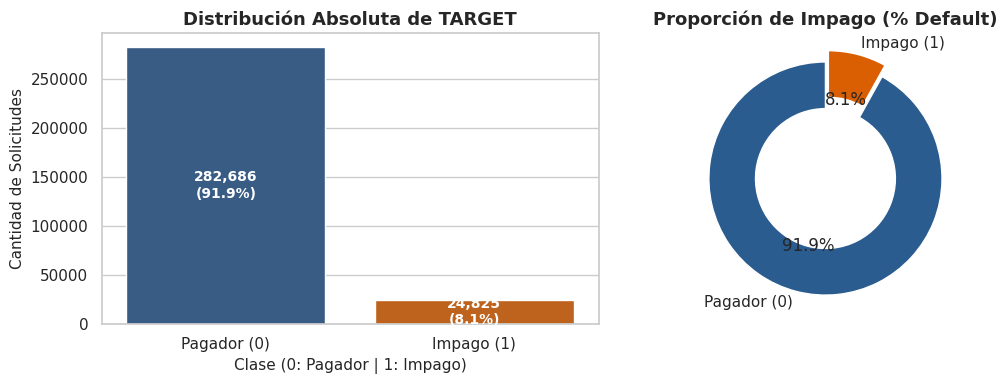

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Cálculo de frecuencias absolutas y porcentuales
target_counts = df["TARGET"].value_counts()
target_perc = df["TARGET"].value_counts(normalize=True) * 100

# Consolidación en DataFrame resumen
target_summary = pd.DataFrame(
    {
        "Cantidad de Registros": target_counts,
        "Porcentaje (%)": target_perc.round(2),
    }
)

print("--- RESUMEN DE LA VARIABLE TARGET ---")
print(target_summary)
print("-" * 38)
print(
    f"Ratio de Desbalance (0 vs 1): {target_counts[0] / target_counts[1]:.2f} : 1"
)

# 2. Visualización de la Distribución del TARGET
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Gráfico de Barras
palette = ["#2b5c8f", "#d95f02"]
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    ax=ax[0],
    palette=palette,
    hue=target_counts.index,
    legend=False,
)
ax[0].set_title(
    "Distribución Absoluta de TARGET", fontsize=13, fontweight="bold"
)
ax[0].set_xlabel("Clase (0: Pagador | 1: Impago)", fontsize=11)
ax[0].set_ylabel("Cantidad de Solicitudes", fontsize=11)
ax[0].set_xticks([0, 1], ["Pagador (0)", "Impago (1)"])

# Agregar valores exactos sobre cada barra
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(
        f"{int(height):,}\n({height / len(df):.1%})",
        (p.get_x() + p.get_width() / 2.0, height / 2),
        ha="center",
        va="center",
        fontsize=10,
        color="white",
        weight="bold",
    )

# Gráfico de Dona (Porcentaje)
colors = ["#2b5c8f", "#d95f02"]
ax[1].pie(
    target_perc,
    labels=["Pagador (0)", "Impago (1)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0, 0.1),
    wedgeprops=dict(width=0.4, edgecolor="w"),
)
ax[1].set_title(
    "Proporción de Impago (% Default)", fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()

## **Análisis Univariado de Variables Cuantitativas Clave**

Se evalúan las principales variables numéricas del perfil financiero del cliente:


*   AMT_INCOME_TOTAL: Ingreso total declarado por el solicitante.
Elemento de lista
*   AMT_CREDIT: Monto total del crédito otorgado.
Elemento de lista

*   AMT_ANNUITY: Cuota o anualidad fijada para la devolución del crédito.

*   AMT_GOODS_PRICE: Precio del bien o servicio para el cual se solicitó el financiamiento.



---


El objetivo metodológico de esta fase es analizar la tendencia central (media, mediana), la dispersión (desviación estándar, rango intercuartílico) y la presencia de asimetría y valores atípicos, los cuales distorsionan los algoritmos si no se identifican a tiempo.

In [28]:
def analizar_variables_numericas(df, lista_columnas, quantile_cutoff=0.999):
    """Calcula estadísticos descriptivos ajustados y grafica histogramas y boxplots

    para variables continuas.
    """
    stats_df = df[lista_columnas].describe().T
    stats_df["skewness"] = df[lista_columnas].skew()
    stats_summary = stats_df[
        ["mean", "std", "min", "50%", "max", "skewness"]
    ].rename(columns={"50%": "median"})

    print("--- ESTADÍSTICOS DESCRIPTIVOS DE VARIABLES NUMÉRICAS ---")
    print(stats_summary.round(2))
    print("-" * 60)

    fig, axes = plt.subplots(len(lista_columnas), 2, figsize=(12, 2.5 * len(lista_columnas)))

    for i, col in enumerate(lista_columnas):
        data_clean = df[col].dropna()

        # Recorte de percentil solo para corregir la escala visual en variables con sesgo extremo
        limit = data_clean.quantile(quantile_cutoff)
        plot_data = data_clean[data_clean <= limit]

        # Histograma / KDE
        sns.histplot(
            plot_data, ax=axes[i, 0], kde=True, color="#2b5c8f", bins=40
        )
        axes[i, 0].set_title(
            f"Distribución de {col} (Filtro < p{quantile_cutoff*100:.1f})",
            fontsize=11,
            fontweight="bold",
        )
        axes[i, 0].set_xlabel("Monto")
        axes[i, 0].set_ylabel("Frecuencia")

        # Boxplot
        sns.boxplot(x=plot_data, ax=axes[i, 1], color="#d95f02")
        axes[i, 1].set_title(
            f"Diagrama de Caja de {col}", fontsize=11, fontweight="bold"
        )
        axes[i, 1].set_xlabel("Monto")

    plt.tight_layout(pad=2.5)
    plt.show()

--- ESTADÍSTICOS DESCRIPTIVOS DE VARIABLES NUMÉRICAS ---
                       mean        std      min    median          max  \
AMT_INCOME_TOTAL  168797.92  237123.15  25650.0  147150.0  117000000.0   
AMT_CREDIT        599026.00  402490.78  45000.0  513531.0    4050000.0   
AMT_ANNUITY        27108.49   14493.46   1615.5   24903.0     258025.5   
AMT_GOODS_PRICE   538316.29  369288.98  40500.0  450000.0    4050000.0   

                  skewness  
AMT_INCOME_TOTAL    391.56  
AMT_CREDIT            1.23  
AMT_ANNUITY           1.58  
AMT_GOODS_PRICE       1.35  
------------------------------------------------------------


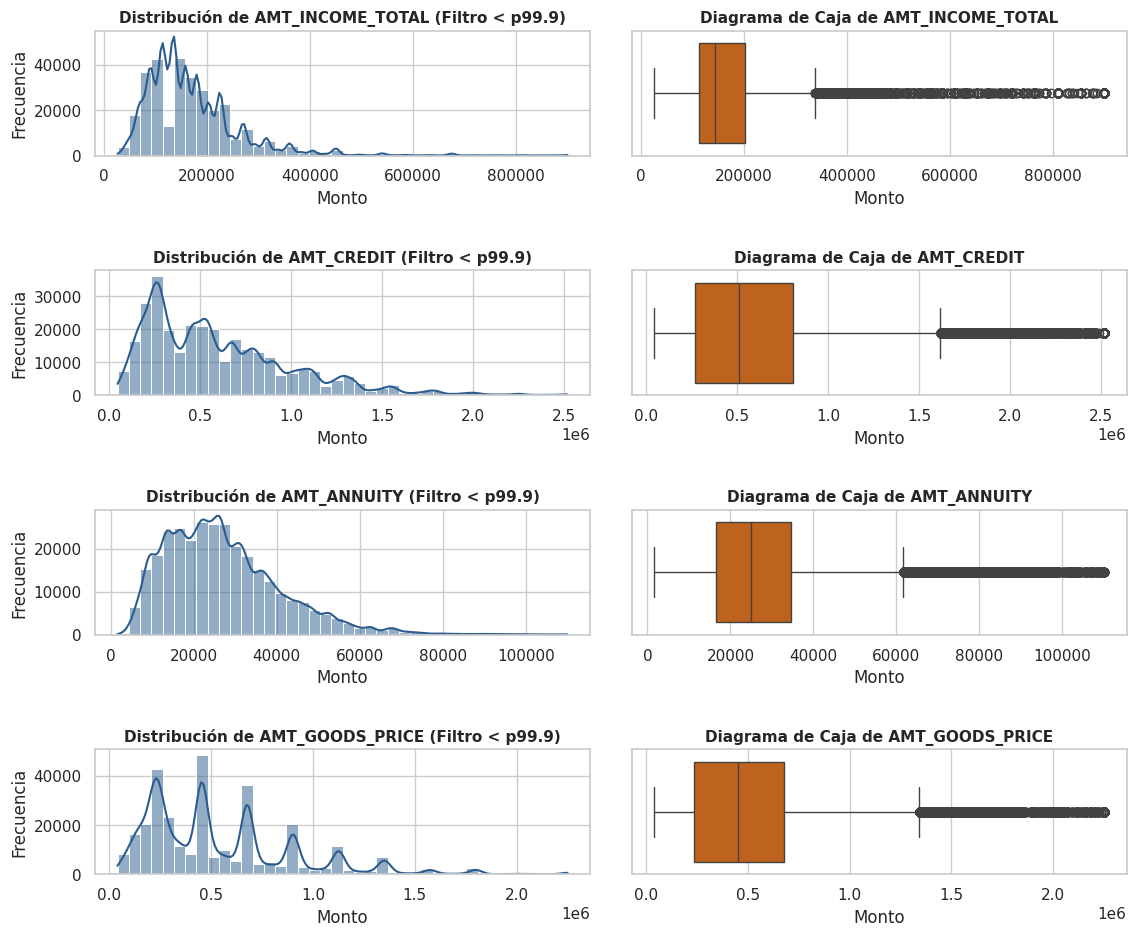

In [29]:
variables_financieras = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]
analizar_variables_numericas(df, lista_columnas=variables_financieras)

### **Interpretación de Métricas de Tendencia Central y Dispersión**

#### **`AMT_INCOME_TOTAL` (Ingreso del Solicitante)**
* **Comportamiento:** La mediana ($147,150.00$) se sitúa sensiblemente por debajo de la media ($168,797.92$), reflejando una asimetría positiva extrema confirmada por un coeficiente de skewness de **391.56**. El valor máximo registrado de $117,000,000.00$ distorsiona significativamente la desviación estándar ($237,123.15$).
* **Conclusión:** El ingreso modal de la población evaluada se concentra en estratos medios-bajos, mientras que un número reducido de observaciones atípicas distorsiona la media aritmética.

#### **`AMT_CREDIT` (Monto del Crédito Solicitado)**
* **Comportamiento:** La mediana es de $513,531.00$ frente a una media de $599,026.00$, con una asimetría moderada (skewness = **1.23**). El rango intercuartílico abarca montos desde $45,000.00$ hasta $4,050,000.00$.
* **Conclusión:** Existe una concentración de créditos en montos de escala pequeña y mediana, con una cola derecha que decrece de manera uniforme a medida que aumenta la cuantía solicitada.

#### **`AMT_ANNUITY` (Cuota Anual/Mensual del Crédito)**
* **Comportamiento:** Presenta una mediana de $24,903.00$ y una media de $27,108.49$, manteniendo una asimetría positiva moderada (skewness = **1.58**). La desviación estándar es de $14,493.46$.
* **Conclusión:** Las obligaciones periódicas están fuertemente acopladas al valor del crédito (`AMT_CREDIT`), reflejando una estructura tarifaria estandarizada según los plazos de amortización.

#### **`AMT_GOODS_PRICE` (Precio del Bien a Financiar)**
* **Comportamiento:** Muestra una mediana de $450,000.00$ y una media de $538,316.29$, con un coeficiente de asimetría de **1.35**. Se observan crestas marcadas en la distribución.
* **Conclusión:** La distribución refleja valores comerciales redondeados o "precios de lista" prefijados por el mercado

### **Diagnóstico de la Estructura de Datos**

* **Presencia Severa de Outliers:**
  Las cuatro variables presentan valores atípicos hacia la cola derecha. En `AMT_INCOME_TOTAL`, el valor de $117\text{ M}$ actúa como un punto de apalancamiento que altera los estimadores paramétricos habituales.

* **Multimodalidad por Factores Comerciales:**
  Tanto `AMT_CREDIT` como `AMT_GOODS_PRICE` presentan picos recurrentes en sus histogramas. Esto demuestra que los montos otorgados no son estrictamente continuos, sino que responden a tramos estandarizados de otorgamiento crediticio.

### **Tratamiento Metodológico de Valores Atípicos (Outliers)**

#### **Justificación Técnica**

En la modelización de riesgo crediticio, el tratamiento de valores atípicos debe equilibrar la conservación de la información real del negocio con la estabilidad de los algoritmos. Los outliers presentes en variables financieras suelen clasificarse en dos tipos:

1. **Errores de registro o valores imposibles:** Registros distorsionados por fallas en la captura de datos que actúan como puntos de apalancamiento, alterando medias, desviaciones estándar y coeficientes de modelos paramétricos.

2. **Valores extremos reales:** Solicitantes con ingresos o créditos inusualmente altos que representan casos atípicos pero legítimos de la población.

Para no eliminar información valiosa ni sesgar el entrenamiento, la mejor práctica consiste en **evitar la eliminación masiva de filas** y aplicar una técnica de **truncamiento (Winsorization)** sobre las colas superiores (percentil 99.9). Esta estrategia limita los valores al umbral máximo permitido sin descartar la observación completa.

---

#### **Diagnóstico y Acción por Variable**

* **AMT_INCOME_TOTAL**
  * **Diagnóstico:** Presenta el sesgo más severo (skewness de **391.56**), con un valor máximo atípico de **$117,000,000.00**

  * **Tratamiento propuesto:** Aplicar Winsorization truncando los valores superiores al percentil 99.9 (p99.9). Esto ajusta el extremo anómalo a un valor representativo del límite superior de ingresos sin distorsionar la distribución.


---


* **AMT_CREDIT**
  * **Diagnóstico:** Presenta un skewness moderado de **1.23**, alcanzando un valor máximo de **$4,050,000.00**. La presencia de valores altos responde a la naturaleza real de créditos hipotecarios o de montos elevados.
  * **Tratamiento propuesto:** Conservación mediante truncamiento suave al percentil 99.9 (p99.9) únicamente para estabilizar modelos paramétricos.

---



* **AMT_ANNUITY**
  * **Diagnóstico:** Muestra una asimetría de **1.58**, con cuotas máximas de **$258,025.50**. Los valores atípicos están alineados con los créditos de mayor volumen (AMT_CREDIT).
  * **Tratamiento propuesto:** Truncamiento al percentil 99.9 (p99.9) para evitar cuotas desproporcionadas .

---



* **AMT_GOODS_PRICE**
  * **Diagnóstico:** Presenta un coeficiente de asimetría de **1.35** y una cola derecha con valores de hasta **$4,050,000.00**, altamente correlacionados con el monto del crédito concedido.
  * **Tratamiento propuesto:** Aplicar el mismo criterio de truncamiento al percentil 99.9 (p99.9) para mantener la coherencia operativa y la paridad analítica con la variable AMT_CREDIT.

In [31]:
# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"


def aplicar_winsorization(df, lista_columnas, percentil=0.999):
    """Aplica truncamiento (Winsorization) en la cola superior (percentil especificado)

    a una lista de columnas numéricas para acotar valores atípicos extremos sin
    eliminar registros.

    Retorna una copia del DataFrame con las variables ajustadas.
    """
    df_clean = df.copy()

    print(
        f"--- APLICANDO WINSORIZATION (TRUNCAMIENTO AL PERCENTIL {percentil * 100:.1f}) ---"
    )
    for col in lista_columnas:
        limite_superior = df_clean[col].quantile(percentil)
        registros_afectados = (df_clean[col] > limite_superior).sum()

        # Truncamiento de valores por encima del percentil
        df_clean[col] = np.where(
            df_clean[col] > limite_superior, limite_superior, df_clean[col]
        )

        print(
            f"Variable '{col}': Límite máximo fijado en {limite_superior:,.2f} | Registros acotados: {registros_afectados:,}"
        )

    print("-" * 75)
    return df_clean


def comparar_distribuciones_outliers(
    df_original, df_ajustado, lista_columnas
):
    """Genera gráficos comparativos (Boxplots) entre el conjunto de datos original

    y el conjunto ajustado por Winsorization.
    """
    num_cols = len(lista_columnas)
    fig, axes = plt.subplots(num_cols, 2, figsize=(12, 2.5 * num_cols))

    for i, col in enumerate(lista_columnas):
        # Gráfico Original
        sns.boxplot(
            x=df_original[col].dropna(), ax=axes[i, 0], color="#d95f02"
        )
        axes[i, 0].set_title(
            f"Original: {col}", fontsize=11, fontweight="bold"
        )
        axes[i, 0].set_xlabel("Monto")

        # Gráfico Ajustado (Post-Winsorization)
        sns.boxplot(
            x=df_ajustado[col].dropna(), ax=axes[i, 1], color="#2b5c8f"
        )
        axes[i, 1].set_title(
            f"Ajustado (Winsorized): {col}", fontsize=11, fontweight="bold"
        )
        axes[i, 1].set_xlabel("Monto")

    plt.tight_layout(pad=2.5)
    plt.show()

--- APLICANDO WINSORIZATION (TRUNCAMIENTO AL PERCENTIL 99.9) ---
Variable 'AMT_INCOME_TOTAL': Límite máximo fijado en 900,000.00 | Registros acotados: 278
Variable 'AMT_CREDIT': Límite máximo fijado en 2,517,300.00 | Registros acotados: 134
Variable 'AMT_ANNUITY': Límite máximo fijado en 110,047.50 | Registros acotados: 306
Variable 'AMT_GOODS_PRICE': Límite máximo fijado en 2,250,000.00 | Registros acotados: 109
---------------------------------------------------------------------------


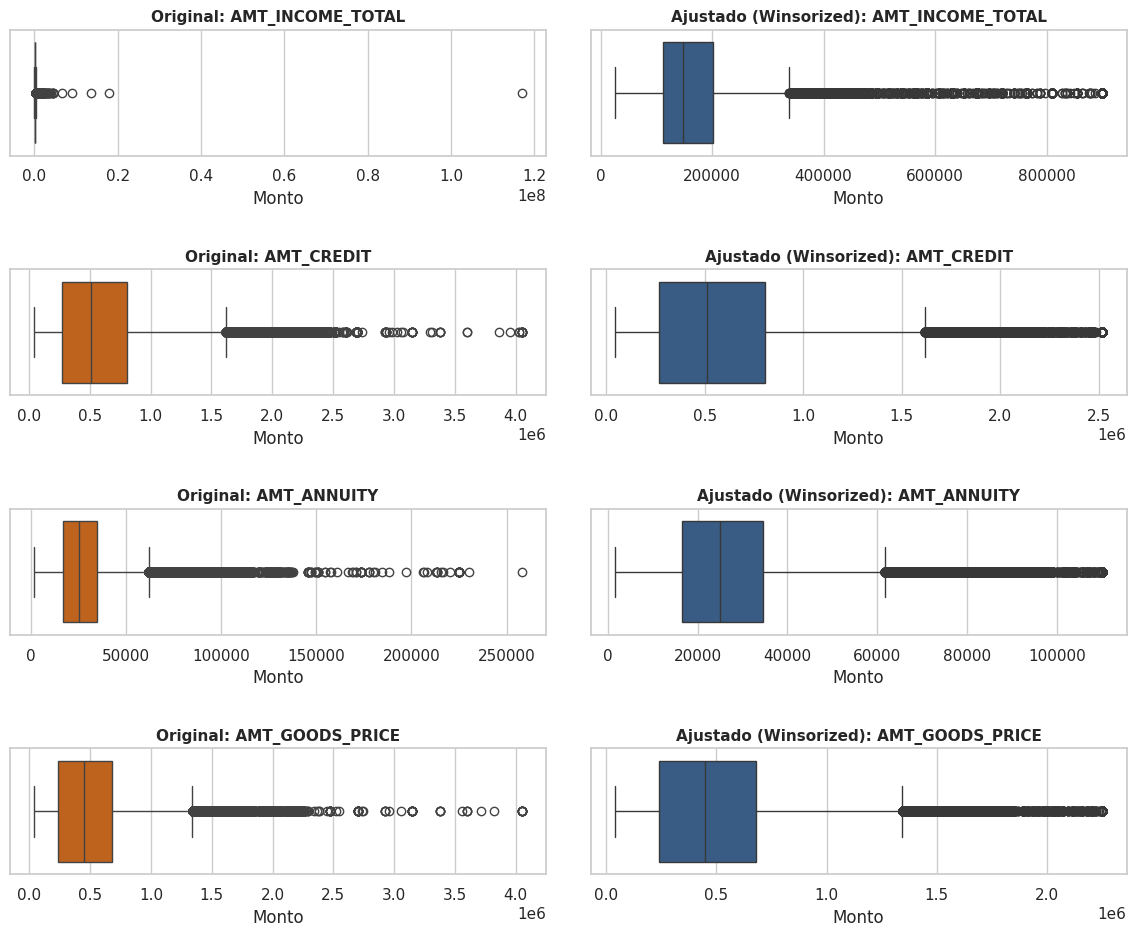

In [32]:
# Lista de variables financieras a tratar
variables_financieras = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

# 1. Aplicar truncamiento al percentil 99.9
df_limpio = aplicar_winsorization(
    df, lista_columnas=variables_financieras, percentil=0.999
)

# 2. Visualizar la comparación del diagnóstico antes y después del tratamiento
comparar_distribuciones_outliers(
    df, df_limpio, lista_columnas=variables_financieras
)

### **Conclusión del Tratamiento de Valores Atípicos**

La aplicación de la técnica de Winsorization en el percentil 99.9% logró estabilizar la estructura analítica de las variables financieras (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY` y `AMT_GOODS_PRICE`) sin perder registros:

* **Eliminación del apalancamiento extremo:** Se neutralizó el impacto desproporcionado del valor atípico de 117,000,000.00 en la variable `AMT_INCOME_TOTAL`, acotando el límite superior a 900,000.00. Esto corrige la distorsión de la media y la desviación estándar.
* **Normalización visual y de escala:** Al reducir el rango dinámico de las variables a topes representativos de la población activa, las distribuciones recuperaron su escala natural en los histogramas y diagramas de caja (boxplots), permitiendo una correcta interpretación de los cuartiles.
* **Preservación de la información de negocio:** A diferencia de una eliminación masiva de filas (truncamiento drástico), solo se acotó un pequeño porcentaje de observaciones extremas (entre 109 y 306 registros por variable), manteniendo intacta la representatividad del portafolio crediticio para la siguiente fase de modelado.

In [34]:
def evaluar_impacto_winsorization(df_orig, df_ajust, lista_columnas):
    """Calcula y muestra la variación en media, desviación estándar y máximo

    entre el conjunto de datos original y el ajustado.
    """
    resumen = []
    for col in lista_columnas:
        resumen.append(
            {
                "Variable": col,
                "Media Orig": df_orig[col].mean(),
                "Media Ajust": df_ajust[col].mean(),
                "Std Orig": df_orig[col].std(),
                "Std Ajust": df_ajust[col].std(),
                "Max Orig": df_orig[col].max(),
                "Max Ajust": df_ajust[col].max(),
            }
        )

    df_resumen = pd.DataFrame(resumen).set_index("Variable")
    print("--- COMPARATIVA DE IMPACTO ESTADÍSTICO ---")
    return df_resumen.round(2)


# Ejecución de la validación
evaluar_impacto_winsorization(
    df, df_limpio, lista_columnas=variables_financieras
)

--- COMPARATIVA DE IMPACTO ESTADÍSTICO ---


,Media Orig,Media Ajust,Std Orig,Std Ajust,Max Orig,Max Ajust
Variable,,,,,,
AMT_INCOME_TOTAL,168797.92,167771.35,237123.15,91928.89,117000000.0,900000.0
AMT_CREDIT,599026.00,598857.66,402490.78,401514.86,4050000.0,2517300.0
AMT_ANNUITY,27108.49,27079.50,14493.46,14254.69,258025.5,110047.5
AMT_GOODS_PRICE,538316.29,538143.41,369288.98,368225.84,4050000.0,2250000.0


### **Transformación de Escala (Transformación Logarítmica)**

En la modelización de riesgo crediticio, muchas variables de monto presentaban una fuerte asimetría hacia la derecha, donde la mayoría de las observaciones se concentran en valores bajos y medios con una cola larga hacia valores elevados. Aunque la Winsorization acotó los valores atípicos extremos, la distribución original sigue distorsionada.

La aplicación de la transformación logarítmica log(1+x) cumple con los siguientes objetivos teóricos:

**Estabilización de la varianza y simetría:** Comprime el rango dinámico de las observaciones de mayor valor, transformando distribuciones altamente asimétricas en curvas acampanadas más cercanas a una distribución normal (gaussiana).

**Optimización para modelos paramétricos:** Algoritmos como Regresión Logística, se asume linealidad o normas numéricas estables. Reducir la escala relativa previene que las variables de mayor magnitud dominen los cálculos de gradiente y distancia.

**Seguridad matemática frente a ceros:** Se utiliza la función log(1+x) en lugar de log(x) para evitar inconsistencias o indefiniciones matemáticas en caso de encontrar montos iguales a cero, asegurando que log(1+0)=0.


---


**Variables a transformar:**

*   AMT_INCOME_TOTAL: Para reducir la asimetría en la distribución del ingreso total del solicitante.

*   AMT_CREDIT: Para homogeneizar la escala de los montos totales de crédito otorgados.
*   AMT_ANNUITY: Para estabilizar la varianza en el valor de las cuotas mensuales de amortización.



In [35]:
def aplicar_transformacion_logaritmica(df, lista_columnas):
    """Aplica la transformación logarítmica log(1 + x) a una lista de variables

    numéricas para reducir la asimetría derecha.

    Crea nuevas columnas con el prefijo 'LOG_' y muestra la comparación del
    coeficiente de asimetría (skewness) antes y después del ajuste.

    Retorna una copia del DataFrame con las nuevas variables agregadas.
    """
    df_transformed = df.copy()

    print(
        "--- APLICANDO TRANSFORMACIÓN LOGARÍTMICA (np.log1p) A VARIABLES NUMÉRICAS ---"
    )
    for col in lista_columnas:
        nombre_nueva_col = f"LOG_{col}"

        # Aplicación de log(1 + x)
        df_transformed[nombre_nueva_col] = np.log1p(df_transformed[col])

        # Cálculo de asimetría
        skew_orig = df_transformed[col].skew()
        skew_log = df_transformed[nombre_nueva_col].skew()

        print(
            f"Variable '{col}': Skewness Original = {skew_orig:.2f} | Skewness Log = {skew_log:.2f}"
        )

    print("-" * 75)
    return df_transformed

In [36]:
# Variables numéricas continuas con asimetría
variables_asimetricas = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

# Aplicar la función sobre el DataFrame limpio
df_limpio = aplicar_transformacion_logaritmica(
    df_limpio, lista_columnas=variables_asimetricas
)

--- APLICANDO TRANSFORMACIÓN LOGARÍTMICA (np.log1p) A VARIABLES NUMÉRICAS ---
Variable 'AMT_INCOME_TOTAL': Skewness Original = 2.36 | Skewness Log = 0.11
Variable 'AMT_CREDIT': Skewness Original = 1.20 | Skewness Log = -0.34
Variable 'AMT_ANNUITY': Skewness Original = 1.22 | Skewness Log = -0.36
---------------------------------------------------------------------------


In [41]:
def comparar_distribuciones_log(df, lista_columnas):
    """Genera gráficos de distribución (Histplot + KDE) para comparar

    las variables originales (Winsorized) contra sus versiones con
    transformación logarítmica (LOG_).
    """
    num_cols = len(lista_columnas)
    fig, axes = plt.subplots(num_cols, 2, figsize=(11, 2.5 * num_cols))

    for i, col in enumerate(lista_columnas):
        # Distribución Original (Post-Winsorization)
        sns.histplot(
            df[col], kde=True, ax=axes[i, 0], color="#2b5c8f", bins=30
        )
        axes[i, 0].set_title(
            f"Original (Winsorized): {col}", fontsize=11, fontweight="bold"
        )
        axes[i, 0].set_xlabel("Monto")

        # Distribución Transformada (Log)
        col_log = f"LOG_{col}"
        sns.histplot(
            df[col_log], kde=True, ax=axes[i, 1], color="#2ca02c", bins=30
        )
        axes[i, 1].set_title(
            f"Transformada: {col_log}", fontsize=11, fontweight="bold"
        )
        axes[i, 1].set_xlabel("Escala Logarítmica log(1+x)")

    plt.tight_layout(pad=2.0)
    plt.show()




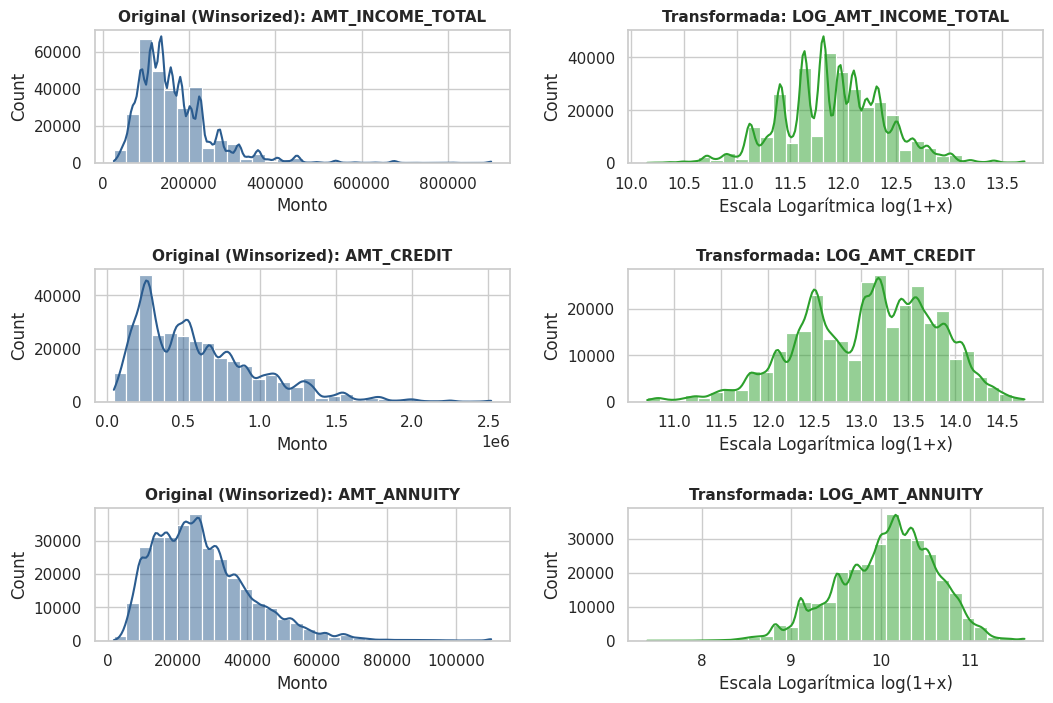

In [42]:
# Ejecutar la verificación visual
comparar_distribuciones_log(df_limpio, variables_asimetricas)

**Conclusión de la Transformación Logarítmica**

La aplicación de la función log(1 + x) sobre las variables continuas logró normalizar la escala analítica de los montos:

* **Corrección de asimetría:** Se comprimieron las colas derechas de `AMT_INCOME_TOTAL`, `AMT_CREDIT` y `AMT_ANNUITY`, convirtiendo distribuciones altamente sesgadas en curvas simétricas y acampanadas.
* **Preparación para modelado:** La reducción de la varianza facilita la convergencia y evita distorsiones de magnitud en algoritmos sensibles a la escala (como Regresión Logística).

In [40]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TARGET                307511 non-null  int64  
 1   NAME_CONTRACT_TYPE    307511 non-null  object 
 2   CODE_GENDER           307511 non-null  object 
 3   FLAG_OWN_CAR          307511 non-null  object 
 4   FLAG_OWN_REALTY       307511 non-null  object 
 5   CNT_CHILDREN          307511 non-null  float64
 6   AMT_INCOME_TOTAL      307511 non-null  float64
 7   AMT_CREDIT            307511 non-null  float64
 8   AMT_ANNUITY           307511 non-null  float64
 9   AMT_GOODS_PRICE       307511 non-null  float64
 10  NAME_INCOME_TYPE      307511 non-null  object 
 11  NAME_EDUCATION_TYPE   307511 non-null  object 
 12  NAME_FAMILY_STATUS    307511 non-null  object 
 13  NAME_HOUSING_TYPE     307511 non-null  object 
 14  DAYS_BIRTH            307511 non-null  int64  
 15  